# Tutorial 3 — Parametric Optimization with Nonlinear Equality + Inequality Constraints

This tutorial shows how to use ENFORCE in **self-supervised mode** — training
purely from an objective function with no labelled outputs.

**Problem:** for each parameter $x \in [2, 4]$, find

$$y^*(x) = \arg\min_{y \in \mathbb{R}^2} \; y_1^2 + y_2^2 \quad \text{s.t.}
  \quad y_1^2 + y_2 = x, \quad y_1 \ge 0$$

- **Equality:** $y_1^2 + y_2 = x$
- **Inequality:** $y_1 \ge 0$ — handled via Fischer-Burmeister reformulation.

By Lagrange multipliers, the unique solution is

$$y_1^* = \sqrt{x - \tfrac{1}{2}}, \quad y_2^* = \tfrac{1}{2}$$

A plain MLP minimising $\|y\|^2$ without projection collapses to $y \approx 0$,
violating the equality constraint $y_1^2 + y_2 = x > 0$.

---

## Key differences from supervised mode

| | Supervised (tutorials 1–2) | Self-supervised (this tutorial) |
|---|---|---|
| Labels | Required | Not needed |
| Training loss | MSE(ŷ, y) | objective f(x, ỹ) |
| `supervised` | `True` | `False` |
| `ssl_loss` | `None` | custom `nn.Module` |

---

## Outline
1. Generate parameter samples  
2. Define the nonlinear equality constraint and inequality  
3. Build the FB wrapper and combined constraint callable  
4. Implement the `ssl_loss` objective  
5. Scale data  
6. Configure ENFORCE and MLP baseline  
7. Train both models  
8. Compare: constraint satisfaction and optimality  

In [ ]:
import sys, pathlib
_here = pathlib.Path.cwd()
_root = _here if (_here / "src").exists() else _here.parent
sys.path.insert(0, str(_root))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from src.enforce.config import ENFORCEConfig
from src.enforce.model import ENFORCE
from src.enforce.fb_inequality_constraints import FischerBurmeisterReformulation
from src.engines.train import Trainer, TrainingConfig
from src.engines.evaluate import Evaluator, EvaluationConfig
from src.data.data_utils import scale_data

np.random.seed(7)
torch.manual_seed(7)

## 1. Generate Parameter Samples

We draw random scalars $x \in [2, 4]$.  No output labels are needed.

In [ ]:
N_TRAIN, N_TEST = 2000, 300

x_train = np.random.uniform(2.0, 4.0, (N_TRAIN, 1)).astype(np.float32)
x_test  = np.linspace(2.0, 4.0, N_TEST).reshape(-1, 1).astype(np.float32)

# Analytical solution — for evaluation only, NOT used during training
y1_opt = np.sqrt(x_test[:, 0] - 0.5).astype(np.float32)  # sqrt(x - 1/2)
y2_opt = np.full(N_TEST, 0.5, dtype=np.float32)           # 1/2
y_opt  = np.column_stack([y1_opt, y2_opt])

print(f"x range: [{x_test.min():.1f}, {x_test.max():.1f}]")
print(f"y1* range: [{y1_opt.min():.3f}, {y1_opt.max():.3f}]")
print(f"y2* = 0.5 (constant)")
print(f"Optimal ||y*||^2 range: [{(y_opt**2).sum(1).min():.3f}, {(y_opt**2).sum(1).max():.3f}]")

x range: [2.0, 4.0]
y1* range: [1.225, 1.871]
y2* = 0.5 (constant)
Optimal ||y*||^2 range: [1.750, 3.750]


## 2. Define the Nonlinear Equality Constraint and Inequality

### Equality: parabola
$$c(x, y) = y_1^2 + y_2 - x = 0$$

Jacobian w.r.t. $(y_1, y_2, \lambda)$:
$$\nabla_y c = [2y_1,\; 1,\; 0]$$

The entry $1$ for $y_2$ guarantees the Gram matrix $G = BB^\top \ge 1$ everywhere,
so the Newton projection is well-conditioned at any initialisation.

### Inequality
$$g(x, y) = -y_1 \le 0 \quad (y_1 \ge 0)$$

In [ ]:
def parabola_constraint(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """y1^2 + y2 = x  ->  c = y1^2 + y2 - x = 0.  Shape [BS, 1]."""
    return (y[:, 0] ** 2 + y[:, 1] - x[:, 0]).unsqueeze(1)

def g_nonneg_y1(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """y1 >= 0  ->  g = -y1 <= 0."""
    return -y[:, 0]

## 3. Build the FB Wrapper and Combined Constraint Callable

The FB wrapper converts $g \le 0$ into an equality residual.  We then combine
it with the equality constraint into a single `[BS, NC]` callable.

**Extended-output convention:**
- Network predicts: `[y1, y2]` (2 neurons)
- `forward()` appends 1 zero column for FB multiplier λ
- Full vector: `y_ext = [y1, y2, λ]`  →  `NO = 3`
- Constraints: `NC = 1 (eq) + 1 (FB) = 2`  →  `NC < NO` ✓

In [ ]:
N_ORIG = 2  # original outputs y1, y2

fb = FischerBurmeisterReformulation(
    n_original_outputs=N_ORIG,
    inequalities=[g_nonneg_y1],
)

def constraints_full(x: torch.Tensor, y_ext: torch.Tensor) -> torch.Tensor:
    """Combined: [equality, FB_ineq].  Shape [BS, 2]."""
    y    = y_ext[:, :N_ORIG]           # original outputs [BS, 2]
    eq   = parabola_constraint(x, y)   # [BS, 1]
    ineq = fb(x, y_ext)                # [BS, 1]
    return torch.cat([eq, ineq], dim=1)

print(f"fb.no     = {fb.no}   (original outputs)")
print(f"fb.n_ineq = {fb.n_ineq}   (FB dual variables)")
print(f"NO        = {fb.no + fb.n_ineq}  (full extended space)")
print(f"NC        = 2  (1 equality + 1 FB)   — NC < NO ✓")

fb.no     = 2   (original outputs)
fb.n_ineq = 1   (FB dual variables)
NO        = 3  (full extended space)
NC        = 2  (1 equality + 1 FB)   — NC < NO ✓


## 4. Implement the SSL Loss

The objective $\|y\|^2 = y_1^2 + y_2^2$ is defined on the **original outputs**
only.  The `ssl_loss` receives the full extended vector `y_ext = [y1, y2, λ]`,
so we slice the first `N_ORIG` columns.

> **Why this ssl_loss is numerically stable:** the gradient of $\|y\|^2$ at
> $y=0$ is $[0, 0]$, but the equality constraint Jacobian is $[0, 1, 0]$ —
> the Newton step immediately pushes $y_2$ toward $x > 0$, breaking the
> degeneracy and driving training forward.

In [ ]:
class MinNormObjective(nn.Module):
    """Minimise ||y_orig||^2 (ignores the FB multiplier column)."""

    def __init__(self, n_orig: int):
        super().__init__()
        self.n_orig = n_orig

    def forward(self, x: torch.Tensor, y_ext: torch.Tensor) -> torch.Tensor:
        y = y_ext[:, :self.n_orig]   # [BS, 2]
        return torch.mean(torch.sum(y ** 2, dim=1))

ssl_loss = MinNormObjective(n_orig=N_ORIG)

## 5. Scale Data

In self-supervised mode there are no output labels.  We pass **zero
placeholders** extended to the full FB space `[N, 3]`.  `scale_data` assigns
`std = 1.0` to zero-std columns (the λ column), leaving it un-normalised.

In [ ]:
y_dummy_train = fb.extend_outputs(np.zeros((N_TRAIN, N_ORIG), dtype=np.float32))
y_dummy_test  = fb.extend_outputs(np.zeros((N_TEST,  N_ORIG), dtype=np.float32))

x_tr_s, y_tr_s, x_te_s, y_te_s, sp = scale_data(
    x_train, y_dummy_train, x_test, y_dummy_test
)

x_tr_t = torch.tensor(x_tr_s, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr_s, dtype=torch.float32)
x_te_t = torch.tensor(x_te_s, dtype=torch.float32)
y_te_t = torch.tensor(y_te_s, dtype=torch.float32)

scaling_input  = (
    torch.tensor(sp["input_mean"],  dtype=torch.float32),
    torch.tensor(sp["input_std"],   dtype=torch.float32),
)
scaling_output = (
    torch.tensor(sp["output_mean"], dtype=torch.float32),
    torch.tensor(sp["output_std"],  dtype=torch.float32),
)

print(f"y_dummy_train shape: {y_dummy_train.shape}  ([N, y1, y2, λ])")

y_dummy_train shape: (2000, 3)  ([N, y1, y2, λ])


## 6. Configure ENFORCE and MLP Baseline

Key settings:

| Setting | Value | Reason |
|---|---|---|
| `output_neurons` | `fb.no = 2` | network predicts y only; λ appended in forward() |
| `supervised` | `False` | use ssl_loss instead of MSE |
| `ada_np_auto_activation` | `True` | skip projection only when it increases the objective |
| `weighting_option` | `1` | unweighted Newton step — safest choice when Jacobians can vary widely |

The MLP (`constrained=False`) minimises $\|y\|^2$ without projection and will
converge to $y \approx 0$, completely violating the equality constraint.

In [ ]:
cfg = ENFORCEConfig(
    input_neurons=1,
    hidden_neurons=64,
    output_neurons=fb.no,   # = 2
    hidden_layers=2,
    training_tolerance=1e-4,
    inference_tolerance=1e-6,
    max_it=100,
    epoch_start_hard_constrained=0,
    ada_np_auto_activation=True,
    supervised=False,
    weight_loss_displacement=0.5,
)

model_enforce = ENFORCE(
    scaling_input=scaling_input,
    scaling_output=scaling_output,
    c=constraints_full,
    fb=fb,
    config=cfg,
    ssl_loss=ssl_loss,
    constrained=True,
    weighting_option=1,
)

model_mlp = ENFORCE(
    scaling_input=scaling_input,
    scaling_output=scaling_output,
    c=constraints_full,
    fb=fb,
    config=cfg,
    ssl_loss=ssl_loss,
    constrained=False,
)

print(f"Network output layer: {model_enforce.output_layer.out_features} neurons  (= fb.no = {fb.no})")
print(f"Full extended space:  {model_enforce.no} dims  (= fb.no + fb.n_ineq = {fb.no + fb.n_ineq})")

Network output layer: 2 neurons  (= fb.no = 2)
Full extended space:  3 dims  (= fb.no + fb.n_ineq = 3)


## 7. Train Both Models

In [ ]:
train_cfg = TrainingConfig(
    batch_size=128,
    epochs=2000,
    learning_rate=1e-3,
    random_seed=7,
    n_original_outputs=fb.no,
)

print("Training ENFORCE...")
model_enforce = Trainer(model_enforce, train_cfg).fit(x_tr_t, y_tr_t)

print("\nTraining MLP baseline...")
model_mlp = Trainer(model_mlp, train_cfg).fit(x_tr_t, y_tr_t)

print("\nDone.")

Training ENFORCE...
Epoch 1/2000, Loss: 5.62e+00, LossDispl: 1.52e+00, EqMeanResidual: 4.90e-06, EqMaxResidual: 3.77e-05, ObjValueOpt: 0.00e+00, ObjValuePred: 4.86e+00
Epoch 2/2000, Loss: 2.93e+00, LossDispl: 2.29e-01, EqMeanResidual: 2.05e-05, EqMaxResidual: 1.08e-04, ObjValueOpt: 0.00e+00, ObjValuePred: 2.81e+00
Epoch 3/2000, Loss: 2.81e+00, LossDispl: 8.41e-02, EqMeanResidual: 5.88e-06, EqMaxResidual: 3.52e-05, ObjValueOpt: 0.00e+00, ObjValuePred: 2.77e+00
Epoch 4/2000, Loss: 2.76e+00, LossDispl: 4.12e-02, EqMeanResidual: 5.73e-07, EqMaxResidual: 3.96e-06, ObjValueOpt: 0.00e+00, ObjValuePred: 2.74e+00
Epoch 5/2000, Loss: 2.75e+00, LossDispl: 2.69e-02, EqMeanResidual: 1.52e-07, EqMaxResidual: 1.16e-06, ObjValueOpt: 0.00e+00, ObjValuePred: 2.74e+00
Epoch 6/2000, Loss: 2.75e+00, LossDispl: 2.04e-02, EqMeanResidual: 1.26e-07, EqMaxResidual: 8.79e-07, ObjValueOpt: 0.00e+00, ObjValuePred: 2.74e+00
Epoch 7/2000, Loss: 2.75e+00, LossDispl: 1.72e-02, EqMeanResidual: 1.28e-07, EqMaxResidual: 

## 8. Compare: Constraint Satisfaction and Optimality

We check:
1. **Equality residual** $|y_1^2 + y_2 - x|$
2. **Inequality violation** — fraction of predictions with $y_1 < 0$
3. **Objective value** $y_1^2 + y_2^2$ vs the optimum $x - \frac{1}{4}$
4. **Distance to the analytical solution** $(\sqrt{x-\tfrac{1}{2}},\; \tfrac{1}{2})$

In [ ]:
eval_cfg = EvaluationConfig(
    batch_size=None,
    n_original_outputs=fb.no,
    inequalities=fb.inequalities,
)

result_enforce = Evaluator(model_enforce, eval_cfg).evaluate(x_te_t, y_te_t, sp)
result_mlp     = Evaluator(model_mlp,     eval_cfg).evaluate(x_te_t, y_te_t, sp)

# Extract original outputs (drop λ); result.predictions is already unscaled by Evaluator
def unscale_and_extract(result):
    return fb.extract_outputs(result.predictions)  # [N, 2]

preds_e = unscale_and_extract(result_enforce)
preds_m = unscale_and_extract(result_mlp)
x_plot  = x_test[:, 0]
obj_opt = x_plot - 0.25  # = y1*^2 + y2*^2 = (x-1/2) + 1/4 = x - 1/4

# 1. Equality residual
res_e = np.abs(preds_e[:, 0]**2 + preds_e[:, 1] - x_plot)
res_m = np.abs(preds_m[:, 0]**2 + preds_m[:, 1] - x_plot)
print("=== Equality residual |y1^2 + y2 - x| ===")
print(f"  ENFORCE — mean: {res_e.mean():.2e},  max: {res_e.max():.2e}")
print(f"  MLP     — mean: {res_m.mean():.2e},  max: {res_m.max():.2e}")

# 2. Inequality violations
viol_e = (preds_e[:, 0] < 0).mean() * 100
viol_m = (preds_m[:, 0] < 0).mean() * 100
print(f"\n=== Inequality violations (y1 < 0) ===")
print(f"  ENFORCE — {viol_e:.1f}% infeasible")
print(f"  MLP     — {viol_m:.1f}% infeasible")

# 3. Objective value
obj_e = (preds_e ** 2).sum(axis=1)
obj_m = (preds_m ** 2).sum(axis=1)
print(f"\n=== Objective ||y||^2 vs optimum (x - 1/4) ===")
print(f"  ENFORCE — mean: {obj_e.mean():.4f}  (optimal: {obj_opt.mean():.4f})")
print(f"  MLP     — mean: {obj_m.mean():.4f}  (optimal: {obj_opt.mean():.4f})")

# 4. Distance to y*
dist_e = np.linalg.norm(preds_e - y_opt, axis=1)
dist_m = np.linalg.norm(preds_m - y_opt, axis=1)
print(f"\n=== Distance to y* = (sqrt(x-1/2), 1/2) ===")
print(f"  ENFORCE — mean: {dist_e.mean():.4f}")
print(f"  MLP     — mean: {dist_m.mean():.4f}")

Projection iterations inference: 2
Inference time: 0.0366s, EqMeanResidual: 1.19e-07, EqMaxResidual: 9.54e-07, ObjValueOpt: 0.00e+00, ObjValuePred: 2.75e+00
Inference time: 0.0124s, EqMeanResidual: 1.50e+00, EqMaxResidual: 4.00e+00, ObjValueOpt: 0.00e+00, ObjValuePred: 7.75e-09
=== Equality residual |y1^2 + y2 - x| ===
  ENFORCE — mean: 2.39e-07,  max: 9.54e-07
  MLP     — mean: 3.00e+00,  max: 4.00e+00

=== Inequality violations (y1 < 0) ===
  ENFORCE — 0.0% infeasible
  MLP     — 0.0% infeasible

=== Objective ||y||^2 vs optimum (x - 1/4) ===
  ENFORCE — mean: 2.7500  (optimal: 2.7500)
  MLP     — mean: 0.0000  (optimal: 2.7500)

=== Distance to y* = (sqrt(x-1/2), 1/2) ===
  ENFORCE — mean: 0.0006
  MLP     — mean: 1.6488


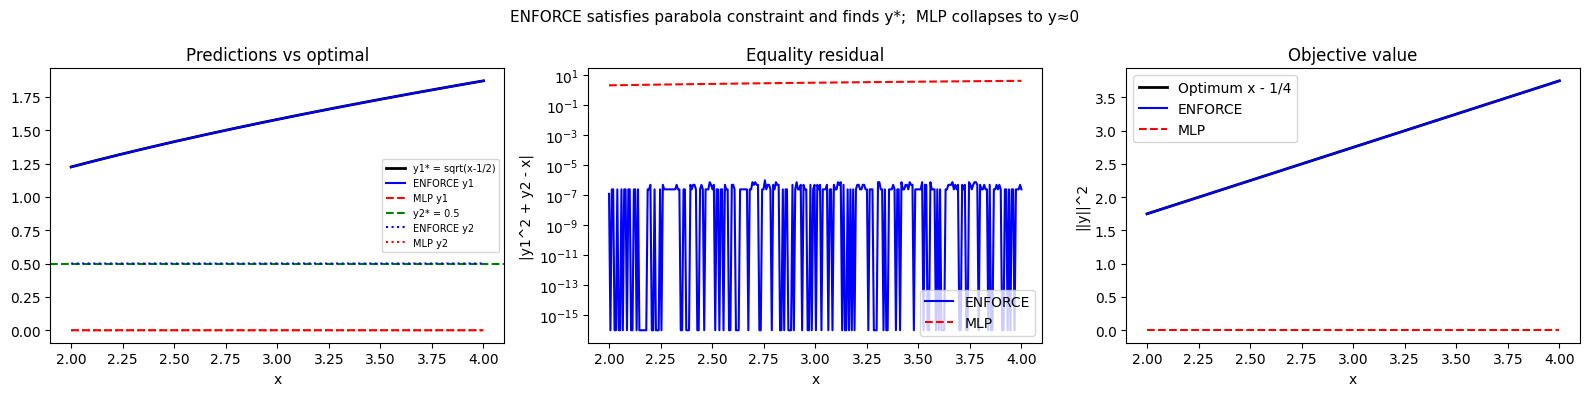

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Panel 1: y1 and y2 predictions vs analytical ──────────────────────────────
ax = axes[0]
ax.plot(x_plot, y1_opt,         'k-',  lw=2,   label='y1* = sqrt(x-1/2)')
ax.plot(x_plot, preds_e[:, 0],  'b-',  lw=1.5, label='ENFORCE y1')
ax.plot(x_plot, preds_m[:, 0],  'r--', lw=1.5, label='MLP y1')
ax.axhline(0.5, color='green', lw=1.5, ls='--', label='y2* = 0.5')
ax.plot(x_plot, preds_e[:, 1],  'b:',  lw=1.5, label='ENFORCE y2')
ax.plot(x_plot, preds_m[:, 1],  'r:',  lw=1.5, label='MLP y2')
ax.set_xlabel('x'); ax.legend(fontsize=7); ax.set_title('Predictions vs optimal')

# ── Panel 2: equality constraint residual ─────────────────────────────────────
ax = axes[1]
ax.semilogy(x_plot, res_e + 1e-16, 'b-',  lw=1.5, label='ENFORCE')
ax.semilogy(x_plot, res_m + 1e-16, 'r--', lw=1.5, label='MLP')
ax.set_xlabel('x'); ax.set_ylabel('|y1^2 + y2 - x|')
ax.set_title('Equality residual'); ax.legend()

# ── Panel 3: objective value ──────────────────────────────────────────────────
ax = axes[2]
ax.plot(x_plot, obj_opt,  'k-',  lw=2,   label='Optimum x - 1/4')
ax.plot(x_plot, obj_e,    'b-',  lw=1.5, label='ENFORCE')
ax.plot(x_plot, obj_m,    'r--', lw=1.5, label='MLP')
ax.set_xlabel('x'); ax.set_ylabel('||y||^2')
ax.set_title('Objective value'); ax.legend()

plt.suptitle('ENFORCE satisfies parabola constraint and finds y*;  MLP collapses to y≈0',
             fontsize=11)
plt.tight_layout()
plt.show()

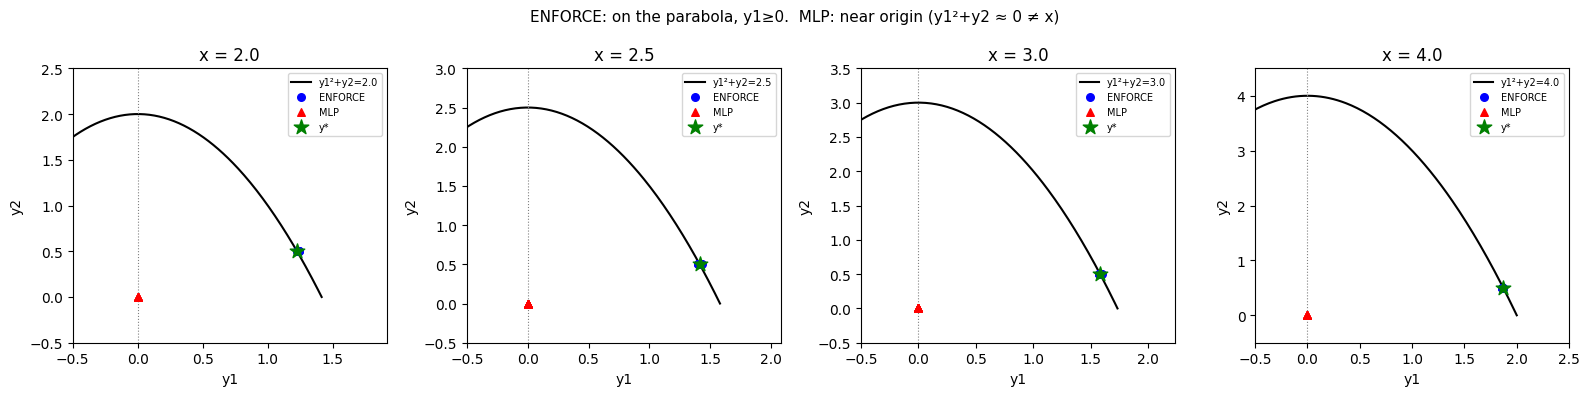

In [ ]:
# Scatter in output space — predictions should lie on the parabola y1^2 + y2 = x
x_vals = [2.0, 2.5, 3.0, 4.0]
fig, axes = plt.subplots(1, len(x_vals), figsize=(16, 4))

for ax, xv in zip(axes, x_vals):
    # Draw the parabola arc y2 = xv - y1^2 for y1 in [-sqrt(xv), sqrt(xv)]
    y1c = np.linspace(-np.sqrt(xv), np.sqrt(xv), 300)
    y2c = xv - y1c ** 2
    ax.plot(y1c, y2c, 'k-', lw=1.5, label=f'y1²+y2={xv}')
    ax.axvline(0, color='grey', lw=0.8, ls=':')

    idx = np.abs(x_test[:, 0] - xv) < 0.05
    if idx.sum() > 0:
        ax.scatter(preds_e[idx, 0], preds_e[idx, 1], s=30, color='blue',
                   zorder=5, label='ENFORCE')
        ax.scatter(preds_m[idx, 0], preds_m[idx, 1], s=30, color='red',
                   marker='^', zorder=5, label='MLP')
        ax.scatter([np.sqrt(xv - 0.5)], [0.5], s=120, color='green',
                   marker='*', zorder=6, label='y*')

    ax.set_xlim(-0.5, np.sqrt(xv) + 0.5)
    ax.set_ylim(-0.5, xv + 0.5)
    ax.set_xlabel('y1'); ax.set_ylabel('y2')
    ax.set_title(f'x = {xv}'); ax.legend(fontsize=7)

plt.suptitle('ENFORCE: on the parabola, y1≥0.  MLP: near origin (y1²+y2 ≈ 0 ≠ x)',
             fontsize=11)
plt.tight_layout()
plt.show()

## Summary

| | Equality residual | Inequality violations | Objective $\|y\|^2$ |
|---|---|---|---|
| ENFORCE | ≈ `inference_tolerance` | 0 % | ≈ $x - \frac{1}{4}$ (optimal) |
| MLP | $\approx x$ (large) | non-zero | $\approx 0$ (infeasible) |

The MLP minimises the objective freely and collapses to $y \approx 0$, which
trivially achieves loss $\approx 0$ but violates $y_1^2 + y_2 = x > 0$.  ENFORCE
projects each prediction onto the parabola, recovers $y_2 = 1/2$, and learns the
mapping $x \mapsto (\sqrt{x - \tfrac{1}{2}},\; \tfrac{1}{2})$.

### Key API recap — mixed constraints, self-supervised

```python
from src.enforce.fb_inequality_constraints import FischerBurmeisterReformulation

# 1. Nonlinear equality  (well-conditioned Jacobian — no zero rows)
def my_eq(x, y):    return (y[:,0]**2 + y[:,1] - x[:,0]).unsqueeze(1)

# 2. Inequality g(x,y) <= 0  via FB
def g(x, y):        return -y[:, 0]
fb = FischerBurmeisterReformulation(n_original_outputs=2, inequalities=[g])

# 3. Combined constraint callable
def c_full(x, y_ext):
    y = y_ext[:, :2]
    return torch.cat([my_eq(x, y), fb(x, y_ext)], dim=1)

# 4. SSL objective (operates on y_ext; slice to ignore λ columns)
class Obj(nn.Module):
    def forward(self, x, y_ext):
        return torch.mean(torch.sum(y_ext[:,:2]**2, dim=1))

# 5. Dummy labels extended to FB space
y_dummy = fb.extend_outputs(np.zeros((N, 2), dtype=np.float32))
_, y_d_s, _, _, sp = scale_data(x_train, y_dummy, x_test, y_dummy)

# 6. Build — output_neurons=fb.no, supervised=False, weighting_option=1
cfg   = ENFORCEConfig(output_neurons=fb.no, supervised=False, ...)
model = ENFORCE(c=c_full, fb=fb, ssl_loss=Obj(), config=cfg,
                constrained=True, weighting_option=1)

# 7. Train / Evaluate
model  = Trainer(model, TrainingConfig(n_original_outputs=fb.no, ...)).fit(...)
result = Evaluator(model, EvaluationConfig(
    n_original_outputs=fb.no, inequalities=fb.inequalities
)).evaluate(...)
preds  = fb.extract_outputs(result.predictions * sp['output_std'] + sp['output_mean'])
```